# Plegado de las curvas de luz

In [1]:
from pathlib import Path

import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
ruta_catalogo = Path(
    "../data/interim/catalogo_maestro.csv"
)

catalogo = pd.read_csv(
    ruta_catalogo,
    dtype={
        "observacion_id": "string",
        "star_id_base": "string",
        "star_id": "string",
        "proyecto_origen": "string",
        "region_origen": "string",
        "ruta_curva": "string",
        "subtipo_rrlyrae": "string",
    },
)

print(f"Archivo encontrado: {ruta_catalogo.exists()}")
print(f"Filas cargadas: {len(catalogo):,}")
print(f"Columnas: {len(catalogo.columns)}")
print(
    "observacion_id únicos: "
    f"{catalogo['observacion_id'].nunique():,}"
)
print(
    "star_id_base únicos: "
    f"{catalogo['star_id_base'].nunique():,}"
)
print(
    "Períodos ausentes o no positivos: "
    f"{(
        catalogo['periodo_catalogo'].isna()
        | (catalogo['periodo_catalogo'] <= 0)
    ).sum():,}"
)

C:\Users\adanm\AppData\Local\Temp\ipykernel_24436\1025579991.py:5: DtypeWarning: Columns (0: transicion) have mixed types. Specify dtype option on import or set low_memory=False.
  catalogo = pd.read_csv(


Archivo encontrado: True
Filas cargadas: 104,008
Columnas: 37
observacion_id únicos: 104,008
star_id_base únicos: 70,269
Períodos ausentes o no positivos: 0


In [ ]:
ruta_periodos = Path("../data/raw/periods")

registros_folding = []

for archivo in sorted(ruta_periodos.glob("*.dat")):
    partes = archivo.stem.split("-")
    proyecto = f"{partes[0]}-{partes[1]}"
    region = partes[2]

    # No existen curvas OGLE-III de GD en el catálogo seleccionado.
    if proyecto == "OGLE-III" and region == "GD":
        continue

    with archivo.open("r", encoding="utf-8") as contenido:
        for linea in contenido:
            if not linea.strip() or linea.lstrip().startswith("#"):
                continue

            campos = linea.split()

            registros_folding.append({
                "proyecto_origen": proyecto,
                "star_id": campos[0],
                "periodo_verificacion": float(campos[3]),
                "error_periodo_catalogo": float(campos[4]),
                "epoca_catalogo": float(campos[5]),
            })

parametros_folding = pd.DataFrame(registros_folding)

catalogo = catalogo.merge(
    parametros_folding,
    on=["proyecto_origen", "star_id"],
    how="left",
    validate="one_to_one",
)

periodos_coincidentes = np.isclose(
    catalogo["periodo_catalogo"],
    catalogo_maestro["periodo_verificacion"],
    rtol=0,
    atol=1e-12,
)

print(f"Filas conservadas: {len(catalogo):,}")
print(
    "Parámetros de folding ausentes: "
    f"{catalogo_maestro[
        [
            'error_periodo_catalogo',
            'epoca_catalogo',
        ]
    ].isna().any(axis=1).sum():,}"
)
print(
    "Períodos coincidentes: "
    f"{periodos_coincidentes.sum():,} de {len(catalogo):,}"
)

Observación: OGLEIII_OGLE-LMC-RRLYR-00001
Subtipo: RRab
Período: 0.6347522
Época: 2184.64705
Mediciones originales: 332
Mediciones plegadas: 332
Intervalo de fase: [0.002245, 0.991111]


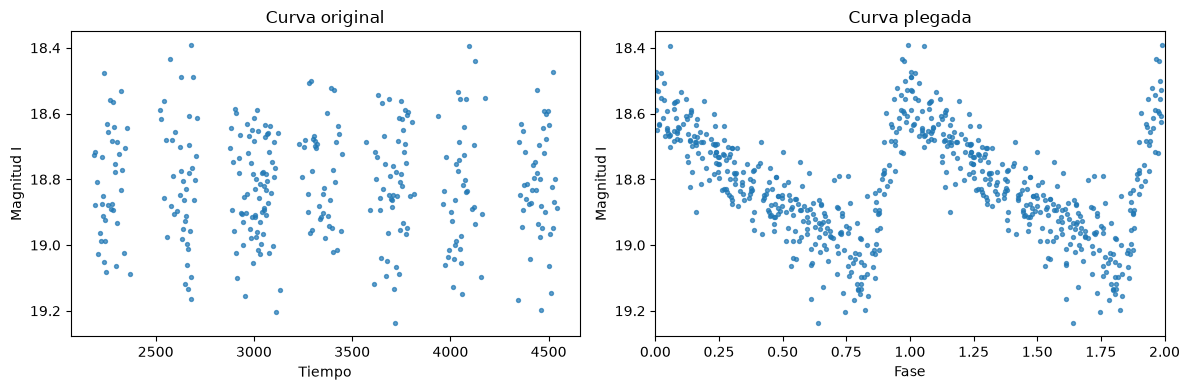

In [6]:
def cargar_y_plegar_curva(fila):
    curva = pd.read_csv(
        fila["ruta_curva"],
        sep=r"\s+",
        names=["tiempo", "magnitud", "error"],
        header=None,
    )

    curva["fase"] = np.mod(
        (
            curva["tiempo"]
            - fila["epoca_catalogo"]
        )
        / fila["periodo_catalogo"],
        1.0,
    )

    curva = (
        curva
        .sort_values("fase")
        .reset_index(drop=True)
    )

    return curva


ejemplo = catalogo.iloc[0]
curva_ejemplo = cargar_y_plegar_curva(ejemplo)

print(f"Observación: {ejemplo['observacion_id']}")
print(f"Subtipo: {ejemplo['subtipo_rrlyrae']}")
print(f"Período: {ejemplo['periodo_catalogo']}")
print(f"Época: {ejemplo['epoca_catalogo']}")
print(f"Mediciones originales: {ejemplo['n_obs_validas']:,}")
print(f"Mediciones plegadas: {len(curva_ejemplo):,}")
print(
    "Intervalo de fase: "
    f"[{curva_ejemplo['fase'].min():.6f}, "
    f"{curva_ejemplo['fase'].max():.6f}]"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

axes[0].scatter(
    curva_ejemplo["tiempo"],
    curva_ejemplo["magnitud"],
    s=8,
    alpha=0.7,
)

axes[0].invert_yaxis()
axes[0].set_title("Curva original")
axes[0].set_xlabel("Tiempo")
axes[0].set_ylabel("Magnitud I")

fase_duplicada = np.concatenate([
    curva_ejemplo["fase"],
    curva_ejemplo["fase"] + 1,
])

magnitud_duplicada = np.concatenate([
    curva_ejemplo["magnitud"],
    curva_ejemplo["magnitud"],
])

axes[1].scatter(
    fase_duplicada,
    magnitud_duplicada,
    s=8,
    alpha=0.7,
)

axes[1].invert_yaxis()
axes[1].set_title("Curva plegada")
axes[1].set_xlabel("Fase")
axes[1].set_ylabel("Magnitud I")
axes[1].set_xlim(0, 2)

plt.tight_layout()
plt.show()

In [ ]:
def graficar_curva_plegada(
    eje,
    curva,
    titulo=None,
    tamaño=8,
    transparencia=0.7,
):
    fase_visual = np.concatenate([
        curva["fase"].to_numpy(),
        curva["fase"].to_numpy() + 1,
    ])

    magnitud_visual = np.concatenate([
        curva["magnitud"].to_numpy(),
        curva["magnitud"].to_numpy(),
    ])

    eje.scatter(
        fase_visual,
        magnitud_visual,
        s=tamaño,
        alpha=transparencia,
    )

    eje.invert_yaxis()
    eje.set_xlim(0, 2)
    eje.set_xlabel("Fase")
    eje.set_ylabel("Magnitud I")

    if titulo is not None:
        eje.set_title(titulo)


fig, eje = plt.subplots(figsize=(8, 4))

graficar_curva_plegada(
    eje,
    curva_ejemplo,
    titulo=(
        f"{ejemplo['observacion_id']} | "
        f"{ejemplo['subtipo_rrlyrae']}"
    ),
)

plt.tight_layout()
plt.show()

print(
    "Mediciones almacenadas: "
    f"{len(curva_ejemplo):,}"
)
print(
    "Puntos mostrados únicamente en la figura: "
    f"{2 * len(curva_ejemplo):,}"
)

In [ ]:
subtipos = sorted(
    catalogo["subtipo_rrlyrae"]
    .dropna()
    .unique()
)

ejemplos_subtipos = []

for subtipo in subtipos:
    grupo = catalogo[
        catalogo["subtipo_rrlyrae"] == subtipo
    ]

    mediana_nobs = grupo["n_obs_validas"].median()

    indice_ejemplo = (
        grupo["n_obs_validas"]
        .sub(mediana_nobs)
        .abs()
        .idxmin()
    )

    ejemplos_subtipos.append(
        catalogo.loc[indice_ejemplo]
    )

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
)

axes = axes.ravel()

for eje, fila in zip(axes, ejemplos_subtipos):
    curva = cargar_y_plegar_curva(fila)

    graficar_curva_plegada(
        eje,
        curva,
        titulo=(
            f"{fila['subtipo_rrlyrae']} | "
            f"{fila['proyecto_origen']} | "
            f"n={len(curva):,}"
        ),
        tamaño=7,
        transparencia=0.65,
    )

for eje in axes[len(ejemplos_subtipos):]:
    eje.axis("off")

plt.tight_layout()
plt.show()

print("Ejemplos utilizados:\n")

for fila in ejemplos_subtipos:
    print(
        f"{fila['subtipo_rrlyrae']}: "
        f"{fila['observacion_id']} | "
        f"P={fila['periodo_catalogo']}"
    )

In [ ]:
registros_prueba = []

for fila in ejemplos_subtipos:
    curva = cargar_y_plegar_curva(fila)

    registros_prueba.append({
        "observacion_id": fila["observacion_id"],
        "fase": curva["fase"].tolist(),
        "magnitud": curva["magnitud"].tolist(),
        "error": curva["error"].tolist(),
        "n_obs_folding": len(curva),
    })

prueba_folding = pd.DataFrame(registros_prueba)

ruta_prueba_folding = Path(
    "../data/interim/prueba_folding.parquet"
)

prueba_folding.to_parquet(
    ruta_prueba_folding,
    index=False,
    engine="pyarrow",
    compression="zstd",
)

prueba_recuperada = pd.read_parquet(
    ruta_prueba_folding,
    engine="pyarrow",
)

print(f"Filas recuperadas: {len(prueba_recuperada)}")
print(f"Columnas: {list(prueba_recuperada.columns)}\n")

for _, fila in prueba_recuperada.iterrows():
    print(
        f"{fila['observacion_id']} | "
        f"fase={len(fila['fase'])} | "
        f"magnitud={len(fila['magnitud'])} | "
        f"error={len(fila['error'])} | "
        f"n={fila['n_obs_folding']}"
    )

ruta_prueba_folding.unlink()

In [ ]:
ruta_folding = Path(
    "../data/interim/curvas_plegadas.parquet"
)

ruta_folding.parent.mkdir(
    parents=True,
    exist_ok=True,
)

if ruta_folding.exists():
    raise FileExistsError(
        f"Ya existe el archivo: {ruta_folding}"
    )

esquema_folding = pa.schema([
    ("observacion_id", pa.string()),
    ("fase", pa.list_(pa.float64())),
    ("magnitud", pa.list_(pa.float32())),
    ("error", pa.list_(pa.float32())),
    ("n_obs_folding", pa.int32()),
])

tamaño_lote = 1_000
registros_resumen_folding = []
total_mediciones_folding = 0

escritor = pq.ParquetWriter(
    ruta_folding,
    esquema_folding,
    compression="zstd",
)

try:
    for inicio in range(
        0,
        len(catalogo),
        tamaño_lote,
    ):
        fin = min(
            inicio + tamaño_lote,
            len(catalogo),
        )

        lote = catalogo.iloc[inicio:fin]

        ids_lote = []
        fases_lote = []
        magnitudes_lote = []
        errores_lote = []
        cantidades_lote = []

        for fila in lote.itertuples(index=False):
            datos = np.loadtxt(
                fila.ruta_curva,
                dtype=np.float64,
                ndmin=2,
            )

            if datos.shape[1] != 3:
                raise ValueError(
                    f"Formato inesperado en "
                    f"{fila.observacion_id}: "
                    f"{datos.shape[1]} columnas"
                )

            tiempo = datos[:, 0]
            magnitud = datos[:, 1]
            error = datos[:, 2]

            fase = np.mod(
                (
                    tiempo
                    - fila.epoca_catalogo
                )
                / fila.periodo_catalogo,
                1.0,
            )

            orden = np.argsort(fase)

            fase = fase[orden]
            magnitud = magnitud[orden]
            error = error[orden]

            n_obs_folding = len(fase)

            if n_obs_folding != fila.n_obs_validas:
                raise ValueError(
                    f"Número de observaciones diferente "
                    f"en {fila.observacion_id}"
                )

            valores_validos = (
                np.isfinite(fase).all()
                and np.isfinite(magnitud).all()
                and np.isfinite(error).all()
                and (fase >= 0).all()
                and (fase < 1).all()
                and (error > 0).all()
            )

            if not valores_validos:
                raise ValueError(
                    f"Valores inválidos en "
                    f"{fila.observacion_id}"
                )

            ids_lote.append(
                fila.observacion_id
            )

            fases_lote.append(
                fase.astype(np.float64)
            )

            magnitudes_lote.append(
                magnitud.astype(np.float32)
            )

            errores_lote.append(
                error.astype(np.float32)
            )

            cantidades_lote.append(
                n_obs_folding
            )

            registros_resumen_folding.append({
                "observacion_id": fila.observacion_id,
                "n_obs_folding": n_obs_folding,
            })

            total_mediciones_folding += (
                n_obs_folding
            )

        tabla_lote = pa.Table.from_arrays(
            [
                pa.array(
                    ids_lote,
                    type=pa.string(),
                ),
                pa.array(
                    fases_lote,
                    type=pa.list_(pa.float64()),
                ),
                pa.array(
                    magnitudes_lote,
                    type=pa.list_(pa.float32()),
                ),
                pa.array(
                    errores_lote,
                    type=pa.list_(pa.float32()),
                ),
                pa.array(
                    cantidades_lote,
                    type=pa.int32(),
                ),
            ],
            schema=esquema_folding,
        )

        escritor.write_table(tabla_lote)

        if fin % 10_000 == 0 or fin == len(catalogo):
            print(
                f"{fin:,} de "
                f"{len(catalogo):,} "
                "curvas procesadas"
            )

except Exception:
    escritor.close()

    if ruta_folding.exists():
        ruta_folding.unlink()

    raise

else:
    escritor.close()

resumen_folding = pd.DataFrame(
    registros_resumen_folding
)

archivo_folding = pq.ParquetFile(
    ruta_folding
)

print(f"\nCurvas plegadas: {len(resumen_folding):,}")
print(
    "Mediciones almacenadas: "
    f"{total_mediciones_folding:,}"
)
print(
    "Grupos internos: "
    f"{archivo_folding.num_row_groups:,}"
)
print(
    "Tamaño del archivo: "
    f"{ruta_folding.stat().st_size / 1024**3:,.2f} GB"
)

In [ ]:
columnas_control = pq.read_table(
    ruta_folding,
    columns=[
        "observacion_id",
        "n_obs_folding",
    ],
).to_pandas()

control_catalogo = catalogo[
    [
        "observacion_id",
        "n_obs_validas",
    ]
].merge(
    columnas_control,
    on="observacion_id",
    how="outer",
    validate="one_to_one",
    indicator=True,
)

grupos_muestra = sorted({
    0,
    archivo_folding.num_row_groups // 2,
    archivo_folding.num_row_groups - 1,
})

incidencias_muestra = 0

for numero_grupo in grupos_muestra:
    tabla_grupo = archivo_folding.read_row_group(
        numero_grupo
    ).to_pandas()

    for fila in tabla_grupo.itertuples(index=False):
        fase = np.asarray(fila.fase)
        magnitud = np.asarray(fila.magnitud)
        error = np.asarray(fila.error)

        correcto = (
            len(fase)
            == len(magnitud)
            == len(error)
            == fila.n_obs_folding
            and np.isfinite(fase).all()
            and (fase >= 0).all()
            and (fase < 1).all()
            and (np.diff(fase) >= 0).all()
        )

        if not correcto:
            incidencias_muestra += 1

print(f"Filas almacenadas: {len(columnas_control):,}")
print(
    "observacion_id únicos: "
    f"{columnas_control['observacion_id'].nunique():,}"
)
print(
    "Mediciones según Parquet: "
    f"{columnas_control['n_obs_folding'].sum():,}"
)
print("\nResultado del cruce con el catálogo:")
print(control_catalogo["_merge"].value_counts().to_string())
print(
    "Diferencias en el número de mediciones: "
    f"{(
        control_catalogo['n_obs_validas']
        != control_catalogo['n_obs_folding']
    ).sum():,}"
)
print(
    "Incidencias en grupos inspeccionados: "
    f"{incidencias_muestra:,}"
)

In [ ]:
catalogo_folding = (
    catalogo
    .drop(columns="periodo_verificacion")
    .merge(
        columnas_control,
        on="observacion_id",
        how="left",
        validate="one_to_one",
    )
)

catalogo_folding["archivo_folding"] = str(
    ruta_folding
)

catalogo_folding["en_catalogo_final"] = True

assert len(catalogo_folding) == 104_008
assert catalogo_folding["observacion_id"].is_unique
assert catalogo_folding["star_id_base"].nunique() == 70_269
assert (
    catalogo_folding["n_obs_folding"]
    == catalogo_folding["n_obs_validas"]
).all()
assert catalogo_folding["en_catalogo_final"].all()

ruta_catalogo_actualizado = Path(
    "../data/interim/catalogo_maestro.csv"
)

catalogo_folding.to_csv(
    ruta_catalogo_actualizado,
    index=False,
    encoding="utf-8",
)

catalogo_verificacion = pd.read_csv(
    ruta_catalogo_actualizado,
    encoding="utf-8",
)

print(f"Catálogo actualizado: {ruta_catalogo_actualizado.resolve()}")
print(f"Filas: {len(catalogo_verificacion):,}")
print(f"Columnas: {len(catalogo_verificacion.columns)}")
print(
    "Incluidas en el catálogo final: "
    f"{catalogo_verificacion['en_catalogo_final'].sum():,}"
)